0.10511112605663978


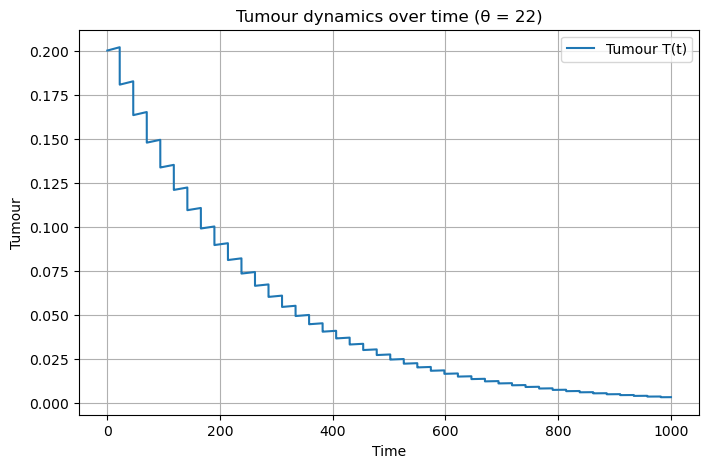

In [1]:
#tumour dynamics over time for a specified dose phase

import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================

r_T = 0.000535 #per hour growth rate per capita
r_H = 0.0001

alpha_bar, A_alpha = 0.25, 0.15
beta_bar, A_beta = 0.15, 0.15

phi_alpha = 11 #based on study showing peak DNA synthesis of ovarian cancer cells occurs around 11am-12 noon
phi_beta = 21 #based on study showing peak DNA synthesis of normal cells occurs around 9-10pm

tau = 24
t_f = 1000
dt = 0.05

T0 = 0.2
H0 = 0.95

theta_fixed = 22


# =========================
# FUNCTIONS
# =========================

def alpha(theta):
    return alpha_bar + A_alpha * np.cos(2*np.pi/24 * (theta - phi_alpha))

def beta(theta):
    return beta_bar + A_beta * np.cos(2*np.pi/24 * (theta - phi_beta))

def logistic_step(x, r, dt):
    return (x * np.exp(r * dt)) / (1 + x * (np.exp(r * dt) - 1))


# =========================
# SIMULATION (T only)
# =========================

t = 0.0
T = T0
H = H0

times = [t]
T_vals = [T]

next_dose = theta_fixed
if next_dose == 0:
    T *= (1 - alpha(theta_fixed))
    H *= (1 - beta(theta_fixed))
    next_dose += tau
    
while t < t_f:
    
    # growth
    T = logistic_step(T, r_T, dt) #approximating dT/dt
    H = logistic_step(H, r_H, dt) #approximating dH/dt
    
    t += dt
    
    # impulse
    if abs(t - next_dose) < dt/2:
        T *= (1 - alpha(theta_fixed))
        H *= (1 - beta(theta_fixed))
        next_dose += tau
    
    times.append(t)
    T_vals.append(T)

print(alpha(theta_fixed))
# =========================
# PLOT
# =========================

plt.figure(figsize=(8,5))
plt.plot(times, T_vals, label="Tumour T(t)")
plt.xlabel("Time")
plt.ylabel("Tumour")
plt.title("Tumour dynamics over time (θ = 22)")
plt.legend()
plt.grid()
plt.show()

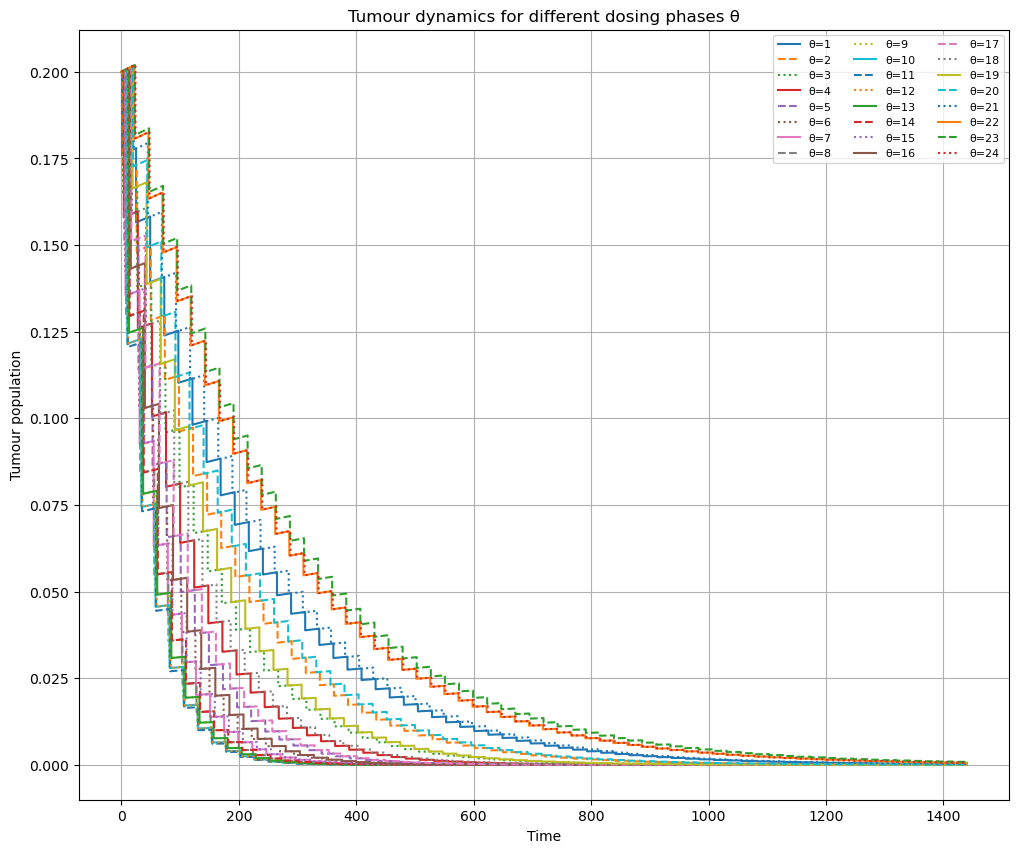

In [2]:
#tumour dynamics over time for 24 different dose phases
#(in terms of dimensionless variables, but will be using notation T to represent the dimensionless x) 

import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================

r_T = 0.000535 #per hour growth rate per capita

alpha_bar, A_alpha = 0.25, 0.15


phi_alpha = 11 #based on study showing peak DNA synthesis of ovarian cancer cells occurs around 11am-12 noon


tau = 24
t_f = 1440 #60 days
dt = 0.05

T0 = 0.2

# =========================
# FUNCTIONS
# =========================

def alpha(theta):
    return alpha_bar + A_alpha * np.cos(2*np.pi/24 * (theta - phi_alpha))

def logistic_step(x, r, dt):
    return (x * np.exp(r * dt)) / (1 + x * (np.exp(r * dt) - 1))

# =========================
# SIMULATION FOR MULTIPLE θ
# =========================

theta_values = np.arange(1, 25, 1)

linestyles = ['-', '--', ':']

plt.figure(figsize=(12,10))

for i, theta_fixed in enumerate(theta_values):
    
    t = 0.0
    T = T0
    
    times = [t]
    T_vals = [T]
    
    next_dose = theta_fixed
    
    while t < t_f:
        T = logistic_step(T, r_T, dt)
        t += dt
        
        if abs(t - next_dose) < dt/2:
            T *= (1 - alpha(theta_fixed))
            next_dose += tau
        
        times.append(t)
        T_vals.append(T)
    
    style = linestyles[i % len(linestyles)]
    plt.plot(times, T_vals, linestyle=style, label=f"θ={theta_fixed}")

plt.legend(ncol=3, fontsize=8)
plt.xlabel("Time")
plt.ylabel("Tumour population")
plt.title("Tumour dynamics for different dosing phases θ")
plt.grid()
plt.show()

Optimal theta (integrated objective for a=3.0, b=1.0, c=1.0): 9.0


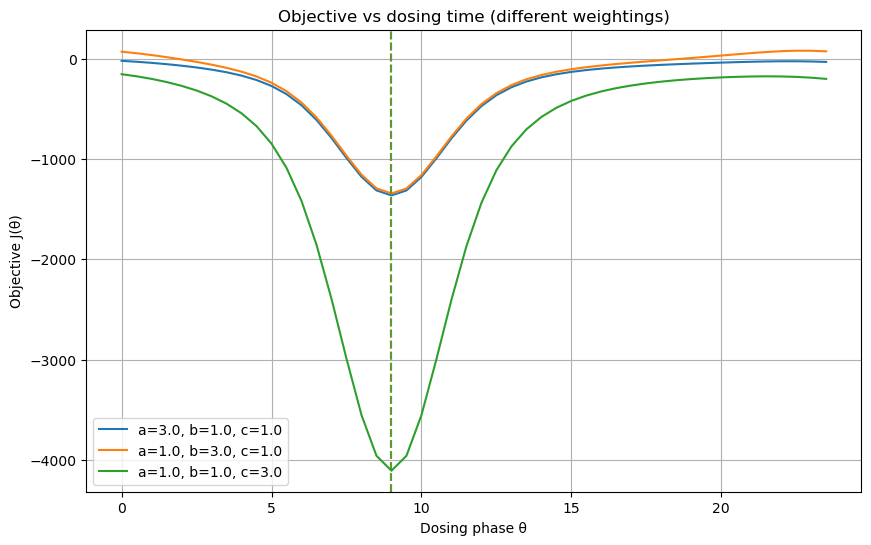

In [3]:
#Time-integrated Objective Function (in terms of dimensionless variables, but will be using notation T and H to represent dimensionless x and y) 

import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================

r_T = 0.000535 #per hour growth rate per capita
r_H = 0.0001 

alpha_bar, A_alpha = 0.25, 0.15
beta_bar, A_beta = 0.15, 0.15

phi_alpha = 11 #based on study showing peak DNA synthesis of ovarian cancer cells occurs around 11am-12 noon
phi_beta = 21 #based on study showing peak DNA synthesis of normal cells occurs around 9-10pm


# Time settings
tau = 24              # dosing interval
t_f = 1440            # total simulation time, 60 days
dt = 0.05              # small timestep for numerical simulation,the “upgrade"- continuous simulation

# Initial conditions

#Important: We are using dimensionless variables x and y as defined in my project, however in this code I refer to x as T and y as H
T0 = 0.2 #tumour starts small
H0 = 0.95 #healthy tissue starts near its full capacity


# =========================
# CIRCADIAN FUNCTIONS 
# =========================

#alpha(phi) and beta(phi), the input is theta (dosing phase) since we'd have already define the parametets phi_alpha and phi_beta above

def alpha(theta): #tumour kill fraction at dosing time
    return alpha_bar + A_alpha * np.cos(2*np.pi/24 * (theta - phi_alpha))

def beta(theta ): #toxicity to healthy cells at dosing time
    return beta_bar + A_beta * np.cos(2*np.pi/24 * (theta - phi_beta))


# =========================
# LOGISTIC STEP 
# =========================
#using the closed form exact solution to the logistic equation, over a small time step dt

def logistic_step(x, r, dt):
    return (x * np.exp(r * dt)) / (1 + x * (np.exp(r * dt) - 1))



# =========================
# FULL SIMULATION (continuous)
# =========================

def simulate(theta):
    t = 0.0
    T = T0
    H = H0
    
    times = [t]
    T_vals = [T]
    H_vals = [H]
    
    
    next_dose = theta  # first dose time occurs at t=theta and next doses are at t= theta+24, theta+48... etc

    if next_dose == 0:
        T *= (1 - alpha(theta))
        H *= (1 - beta(theta))
        next_dose += tau
    
    while t < t_f: #simulate until the decided final time
        
        # Grow continuously
        T = logistic_step(T, r_T, dt) #approximating dT/dt
        H = logistic_step(H, r_H, dt) #approximating dH/dt
        
        t += dt 
                
        # Checking if it's time for a dose (allow tolerance)
        if abs(t - next_dose) < dt/2: #is the current time a dosing time?
            T *= (1 - alpha(theta)) #if yes, implement these jump conditions
            H *= (1 - beta(theta))
            next_dose += tau #schedule next dose aka next dose= t+24

        
        times.append(t)
        T_vals.append(T)
        H_vals.append(H)
    
    return np.array(times), np.array(T_vals), np.array(H_vals) #full trajectories T(t),H(t)





# =========================
# OBJECTIVE FUNCTION
# =========================

def objective_integral(theta, a=3.0, b=1.0, c=1.0):
    times, T_vals, H_vals = simulate(theta)
    
    dt_array = np.diff(times) #computing change in time
    integral = np.sum((b*T_vals[:-1] - c*H_vals[:-1]) * dt_array) #approximates our integral term using a Riemann sum
    
    return a*T_vals[-1] + integral #returns full time-integrated objective function





# =========================
# OPTIMISATION OVER THETA
# =========================

thetas = np.linspace(0, 24, 48, endpoint=False) #testing 144 different dosing times within the 24 hour period

#evaluate objective for each theta:

J_int = [objective_integral(th) for th in thetas]


theta_star_int = thetas[np.argmin(J_int)] #aim is to minimise the time-integrated objective function


print("Optimal theta (integrated objective for a=3.0, b=1.0, c=1.0):", theta_star_int)








# =========================
# PLOT OBJECTIVE FUNCTION FOR DIFFERENT a,b,c WEIGHTINGS
# =========================

theta_vals = np.arange(0, 24, 0.5)
T_final = []

for theta in theta_vals:
    _, T_vals, _ = simulate(theta)
    T_final.append(T_vals[-1])

weight_sets = [
    (3.0, 1.0, 1.0),   # baseline
    (1.0, 3.0, 1.0),  # more tumour penalty
    (1.0, 1.0, 3.0)    # more toxicity penalty
]

colors = ['tab:blue', 'tab:orange', 'tab:green']
labels = [
    "a=3.0, b=1.0, c=1.0",
    "a=1.0, b=3.0, c=1.0",
    "a=1.0, b=1.0, c=3.0"
]


plt.figure(figsize=(10,6))

for (x, y, z), color, label in zip(weight_sets, colors, labels):
    
    J_vals = [objective_integral(th, x, y, z) for th in thetas]
    theta_star = thetas[np.argmin(J_vals)]
    
    plt.plot(thetas, J_vals, color=color, label=label)
    plt.axvline(theta_star, color=color, linestyle='--', alpha=0.7)

plt.xlabel("Dosing phase θ")
plt.ylabel("Objective J(θ)")
plt.title("Objective vs dosing time (different weightings)")
plt.legend()
plt.grid()
plt.show()


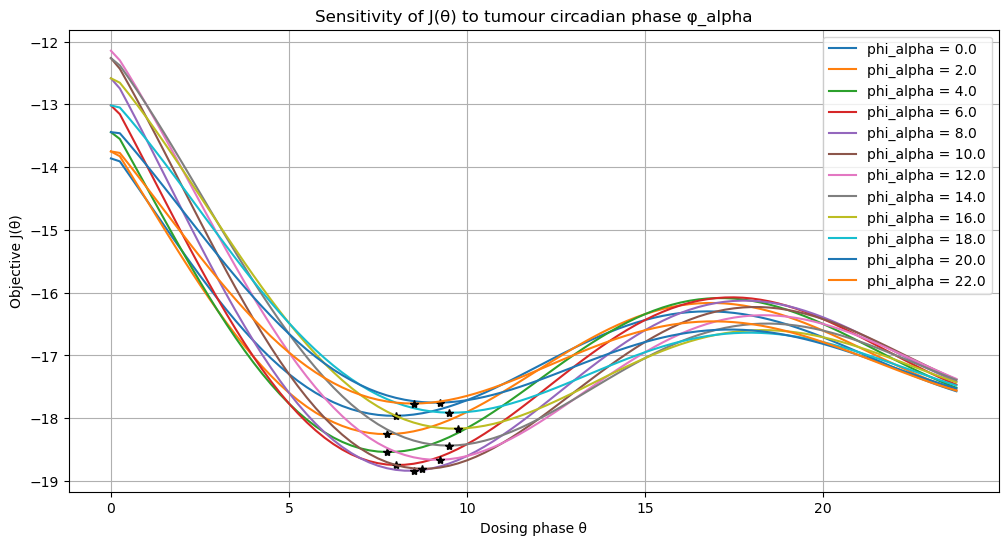

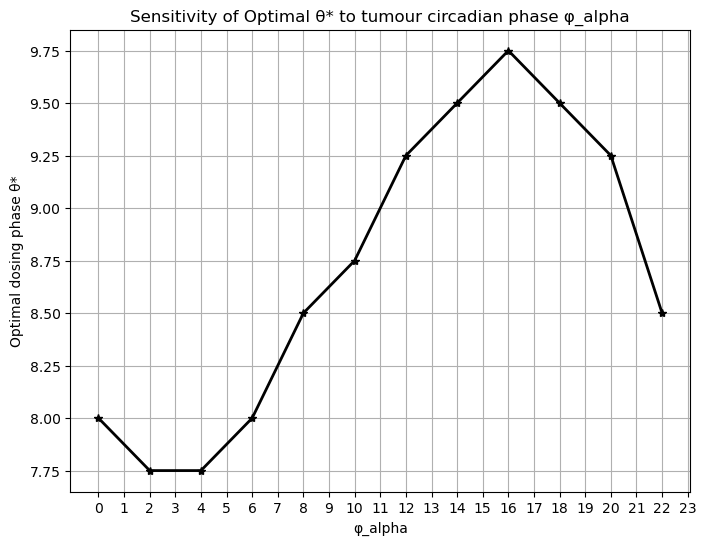

In [5]:
#sensitivty analysis for phi_alpha (in terms of dimensionless variables, but will be using notation T and H to represent dimensionless x and y)


import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================

r_T = 0.000535 #per hour growth rate per capita
r_H = 0.0001

alpha_bar, A_alpha = 0.25, 0.15
beta_bar, A_beta = 0.15, 0.15

phi_alpha = 11 #based on study showing peak DNA synthesis of ovarian cancer cells occurs around 11am-12 noon
phi_beta = 21 #based on study showing peak DNA synthesis of normal cells occurs around 9-10pm


# Time settings
tau = 24              # dosing interval
t_f = 24            # total simulation time, 1 day
dt = 0.05              # small timestep for numerical simulation,the “upgrade"- continuous simulation

# Initial conditions
T0 = 0.2 #tumour starts small
H0 = 0.95 #healthy tissue starts near its full capacity


# =========================
# CIRCADIAN FUNCTIONS 
# =========================



def alpha(theta, phi_alpha_varied):
    return alpha_bar + A_alpha * np.cos(2*np.pi/24 * (theta - phi_alpha_varied))

def beta(theta): #toxicity to healthy cells at dosing time
    return beta_bar + A_beta * np.cos(2*np.pi/24 * (theta - phi_beta))


# =========================
# LOGISTIC STEP 
# =========================
#using the closed form exact solution to the logistic equation, over a small time step dt

def logistic_step(x, r, dt):
    return (x * np.exp(r * dt)) / (1 + x * (np.exp(r * dt) - 1))



# =========================
# FULL SIMULATION (continuous)
# =========================

def simulate(theta, phi_alpha_varied):
    t = 0.0
    T = T0
    H = H0
    
    times = [t]
    T_vals = [T]
    H_vals = [H]
    
    next_dose = theta
    
    if next_dose == 0:
        T *= (1 - alpha(theta, phi_alpha_varied))
        H *= (1 - beta(theta))
        next_dose += tau
    
    while t < t_f: #simulate until the decided final time
            
        # growth
        T = logistic_step(T, r_T, dt)
        H = logistic_step(H, r_H, dt)
        
        t += dt
        
        # impulse
        if abs(t - next_dose) < dt/2:
            T *= (1 - alpha(theta, phi_alpha_varied))
            H *= (1 - beta(theta))  # phi_beta stays fixed
            next_dose += tau
        
        times.append(t)
        T_vals.append(T)
        H_vals.append(H)
    
    return np.array(times), np.array(T_vals), np.array(H_vals)
    

# =========================
# OBJECTIVE FUNCTION
# =========================


def objective_integral(theta, phi_alpha_varied, a=3.0, b=1.0, c=1.0):
    times, T_vals, H_vals = simulate(theta, phi_alpha_varied)
    
    dt_array = np.diff(times)
    integral = np.sum((b*T_vals[:-1] - c*H_vals[:-1]) * dt_array)
    
    return a*T_vals[-1] + integral


thetas = np.linspace(0, 24, 96, endpoint=False) #testing 96 different dosing times within the 24 hour period


# =========================
# Plot phi_alpha sensitivity
# =========================

phi_alpha_values = np.linspace(0, 24, 12, endpoint= False)  # e.g.  testing 12 different max sensitivty phases


plt.figure(figsize=(12,6))


theta_stars = []


for phi_a in phi_alpha_values:

    # compute objective for all theta
    J_vals = [objective_integral(th, phi_a) for th in thetas]
    
    # find optimal theta
    theta_star = thetas[np.argmin(J_vals)]
    theta_stars.append(theta_star)
    
    # plot objective curve for this phi_alpha
    plt.plot(thetas, J_vals, label=f"phi_alpha = {phi_a:.1f}")
    # mark optimal theta on curve
    plt.plot(theta_star, np.min(J_vals), '*', color='black')

plt.xlabel("Dosing phase θ")
plt.ylabel("Objective J(θ)")
plt.title("Sensitivity of J(θ) to tumour circadian phase φ_alpha")
plt.legend()
plt.grid()
plt.show()

#Plot theta* vs phi_alpha
plt.figure(figsize=(8,6))
plt.plot(phi_alpha_values, theta_stars, '-*', color='black', markersize=6, linewidth=2)
plt.xlabel("φ_alpha")
plt.xticks(np.arange(0, 24, 1))
plt.ylabel("Optimal dosing phase θ*")
plt.title("Sensitivity of Optimal θ* to tumour circadian phase φ_alpha")
plt.grid()
plt.show()
 
